# Analyse des mobilités résidentielles entre villes françaises

Le fichier `edges_mobilites.csv` contient des paires `(source, target)` représentant des flux de personnes qui ont déménagé d'une ville à une autre. Chaque ligne correspond à un lien (une **arête**) du graphe.

## Structure de l'analyse
1. Chargement et exploration des données
2. Construction du graphe orienté
3. Propriétés globales du graphe
4. Distribution des degrés (loi de puissance)
5. Analyse des voisins (corrélations de degrés)
6. Robustesse du réseau
7. Intégration des volumes de migration

## 1. Import des bibliothèques

In [50]:
from io import BytesIO
from zipfile import ZipFile
from urllib.request import urlopen
import warnings


import networkx as nx
import itertools
import collections
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import scipy.stats
from scipy.optimize import curve_fit

warnings.filterwarnings('ignore')
import community as community_louvain  # python-louvain


## 2. Chargement des données de mobilité

On charge le fichier CSV contenant les arêtes du graphe de mobilité.
- La colonne `source` = nom de la ville de départ
- La colonne `target` = nom de la ville d'arrivée

In [36]:
df = pd.read_csv(
    "edges_mobilites.csv",
    dtype={"source": str, "target": str}
)

print(df.head())
print(f"\nNombre total de liens de mobilité : {len(df):,}")

                    source                      target
0  L'Abergement-Clémenciat    Châtillon-sur-Chalaronne
1  L'Abergement-Clémenciat  Saint-Trivier-sur-Moignans
2  L'Abergement-Clémenciat                    Sulignat
3  L'Abergement-Clémenciat                   Vitrolles
4  L'Abergement-Clémenciat       Boucoiran-et-Nozières

Nombre total de liens de mobilité : 405,508


## 3. Construction du graphe orienté (DiGraph)

On utilise un **graphe orienté** (`DiGraph`) car les mobilités ont une direction.
Chaque **nœud** représente une ville, chaque **arête** représente un flux migratoire entre deux villes.

In [37]:
G = nx.from_pandas_edgelist(df, source="source", target="target", create_using=nx.DiGraph())

print(f"  - Nombre de nœuds (villes) : {G.number_of_nodes():,}")
print(f"  - Nombre d'arêtes (flux)   : {G.number_of_edges():,}")

  - Nombre de nœuds (villes) : 30,782
  - Nombre d'arêtes (flux)   : 404,835


## 4. Propriétés globales du graphe

### Densité du réseau
La **densité** mesure la fraction des connexions réellement présentes par rapport au nombre maximal possible.

$$\text{densité} = \frac{\text{nombre d'arêtes}}{N \times (N-1)}$$

où $N$ est le nombre de nœuds.

In [38]:
n_nodes = G.number_of_nodes()
n_edges = G.number_of_edges()
density = nx.density(G)


print(f"Densité         : {density:.6f}")
print(f"\nSeulement {density*100:.4f}% des connexions possibles entre villes existent.")

Densité         : 0.000427

Seulement 0.0427% des connexions possibles entre villes existent.


## 5. Distribution des degrés

Le **degré** d'un nœud est le nombre de connexions qu'il possède (ici : nombre de villes reliées par des flux migratoires).

### Fonctions utilitaires
On définit deux fonctions :
- `logBinning` : regroupe les données en **intervalles logarithmiques**, ce qui est nécessaire pour visualiser une loi de puissance sur plusieurs ordres de grandeur.
- `powerLaw` : définit la forme $P(k) = b \cdot k^a$ pour ajuster une loi de puissance.

In [39]:
def logBinning(degreeList, nbin):
    """Découpe la distribution en intervalles logarithmiques."""
    kmin = min(degreeList)
    kmax = max(degreeList)
    logBins = np.logspace(np.log10(kmin), np.log10(kmax), num=nbin)
    logBinDensity, binedges = np.histogram(degreeList, bins=logBins, density=True)
    logBins = np.delete(logBins, -1)
    return logBinDensity, logBins

def powerLaw(x, a, b):
    """Loi de puissance : P(k) = b * k^a."""
    return b * x**(a)

### 5.1 Histogramme brut des degrés

On commence par un histogramme simple. La distribution est très **asymétrique** : la grande majorité des villes ont peu de connexions, mais quelques grandes villes (hubs) en ont beaucoup.

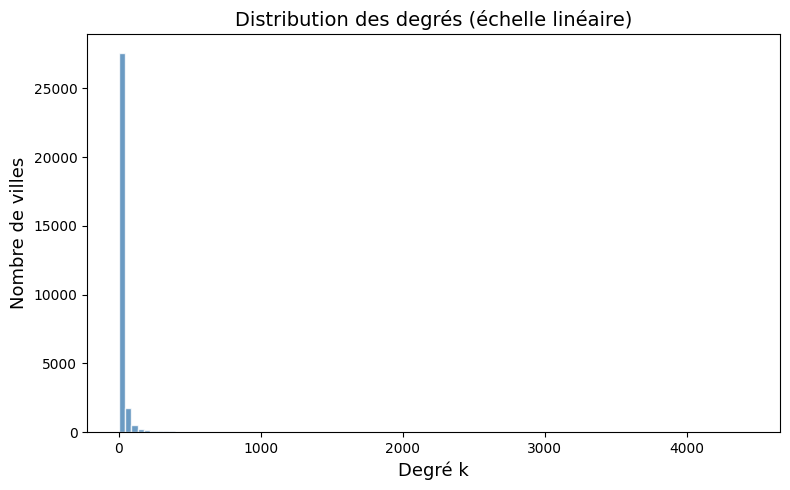

Degré minimum : 1
Degré maximum : 4435
Degré moyen   : 26.3


In [40]:
# Calcul des degrés de tous les nœuds
kDict = dict(G.degree())
kValues = list(kDict.values())

plt.figure(figsize=(8, 5))
plt.hist(kValues, bins=100, color='steelblue', edgecolor='white', alpha=0.8)
plt.xlabel('Degré k', size=13)
plt.ylabel('Nombre de villes', size=13)
plt.title('Distribution des degrés (échelle linéaire)', size=14)
plt.tight_layout()
plt.show()

print(f"Degré minimum : {min(kValues)}")
print(f"Degré maximum : {max(kValues)}")
print(f"Degré moyen   : {np.mean(kValues):.1f}")

### 5.2 Distribution en log-log et loi de puissance

En échelle log-log, si la distribution suit une **loi de puissance** $P(k) \sim k^{-\gamma}$, on obtient une droite.

Exposant γ estimé : -2.530


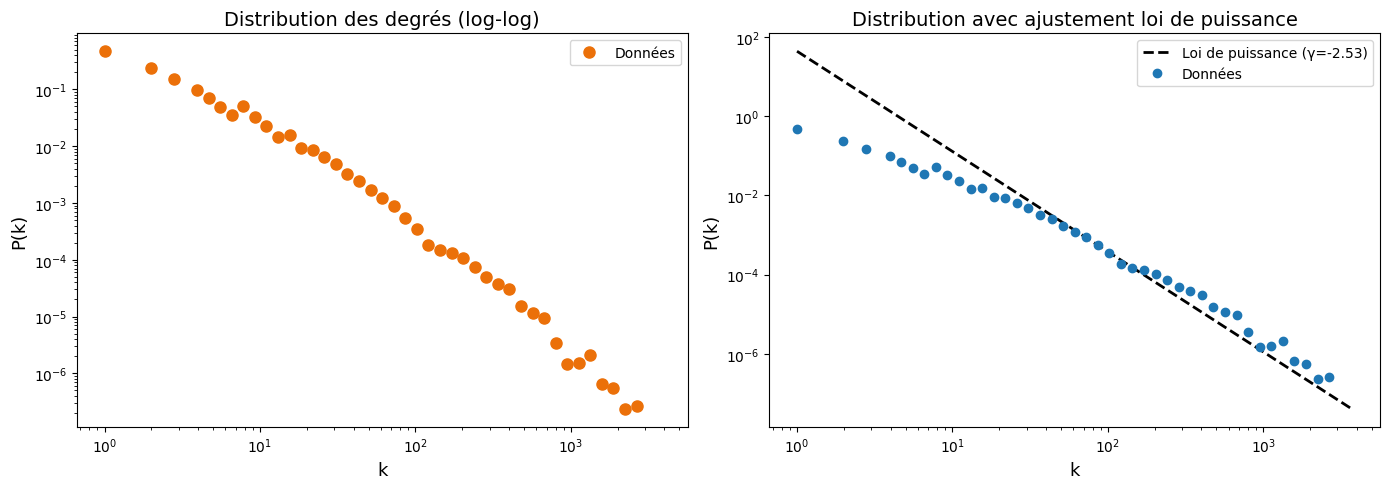

In [41]:
pk, k = logBinning(kValues, 50)

# Ajustement de la loi de puissance sur la partie centrale [70, 1000]
fitx = [u for (u, v) in zip(k, pk) if (u > 70 and u < 1000)]
fity = [v for (u, v) in zip(k, pk) if (u > 70 and u < 1000)]

popt, pcov = curve_fit(powerLaw, fitx, fity)
gamma = popt[0]
print(f"Exposant γ estimé : {gamma:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution log-log
axes[0].loglog(k, pk, 'o', color='#EB7009', markersize=8, label='Données')
axes[0].set_xlabel('k', size=13)
axes[0].set_ylabel('P(k)', size=13)
axes[0].set_title('Distribution des degrés (log-log)', size=14)
axes[0].legend()

# Avec ajustement
axes[1].loglog(sorted(k), powerLaw(sorted(k), *popt), '--', c='k',
               linewidth=2, label=f'Loi de puissance (γ={gamma:.2f})')
axes[1].loglog(k, pk, 'o', label='Données')
axes[1].set_xlabel('k', size=13)
axes[1].set_ylabel('P(k)', size=13)
axes[1].set_title('Distribution avec ajustement loi de puissance', size=14)
axes[1].legend()

plt.tight_layout()
plt.show()

Exposant $\gamma ≈ -2.4$ (pente de la droite en log-log)

Cet exposant est caractéristique des **réseaux sans échelle** (*scale-free networks*), comme observé dans de nombreux réseaux sociaux et géographiques. Cela signifie :
- La majorité des villes ont peu de connexions
- Quelques grandes métropoles jouent un rôle de **hub** dans les mobilités nationales

## 6. Analyse des corrélations de degrés : knn(k)

Pour chaque nœud, on calcule le **degré moyen de ses voisins** (knn = *k nearest neighbors*).

En traçant knn en fonction du degré k :
- **Réseau assortatif** : knn augmente avec k → les hubs se connectent entre eux
- **Réseau disassortatif** : knn diminue avec k → les hubs se connectent à des petites villes

c:\Users\jonas\OneDrive - GENES\Documents\0 ENSAE\3A\S2\Social_network\Rendu final\migrations_villes\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\jonas\OneDrive - GENES\Documents\0 ENSAE\3A\S2\Social_network\Rendu final\migrations_villes\.venv\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


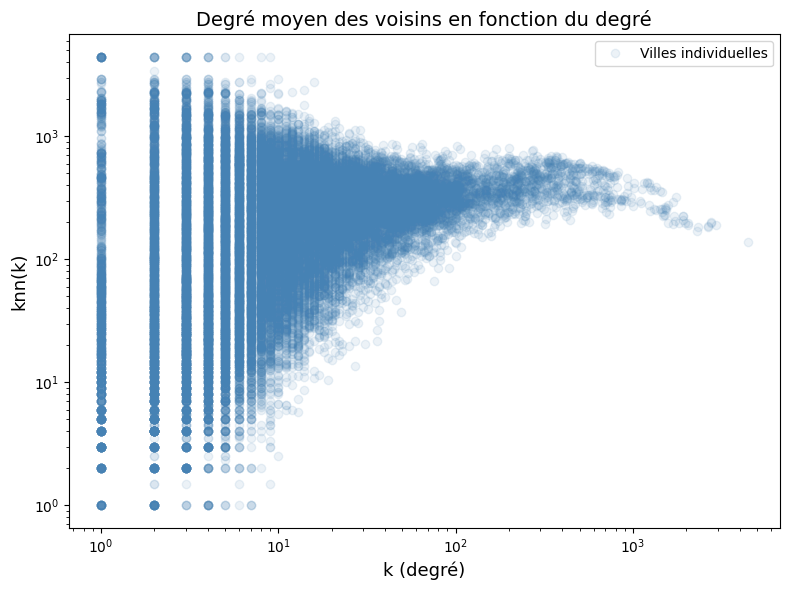

In [42]:
# Calcul du degré moyen des voisins pour chaque nœud
knn = {}
for n in G.nodes():
    neighbors_degrees = [kDict[v] for v in G.neighbors(n)]
    knn[n] = np.mean(neighbors_degrees)

xx = [kDict[n] for n in knn.keys()]
yy = [knn[n] for n in knn.keys()]

plt.figure(figsize=(8, 6))
plt.loglog(xx, yy, 'o', alpha=0.1, color='steelblue', label='Villes individuelles')
plt.xlabel('k (degré)', size=13)
plt.ylabel('knn(k)', size=13)
plt.title('Degré moyen des voisins en fonction du degré', size=14)
plt.legend()
plt.tight_layout()
plt.show()

---

# PARTIE 2 : Intégration des volumes de migration

Vous disposez d'un fichier contenant le **nombre de migrations** associé à chaque flux `(source, target)`. Voici comment l'intégrer à l'analyse.

## Format attendu du fichier

Le fichier de migrations doit contenir au moins ces colonnes :
- `source` : code INSEE de la ville de départ
- `target` : code INSEE de la ville d'arrivée  
- `nb_migrations` (ou un nom similaire) : nombre de personnes ayant effectué ce déplacement

## Étape 1 : Chargement du fichier de migrations

In [43]:
# ADAPTEZ le nom du fichier et de la colonne à votre cas
# Exemple si le fichier s'appelle 'migrations.csv' avec une colonne 'volume'

df_merged = pd.read_csv(
     "edges_mobilites_nb.csv",  # <-- adaptez le nom du fichier
     dtype={"source": str, "target": str, "nb_migrations": float}
)
print(df_merged.head())
print(f"\nVolume total de migrations : {df_merged['nb_migrations'].sum():,}")

                    source                      target  nb_migrations
0  L'Abergement-Clémenciat    Châtillon-sur-Chalaronne       9.817143
1  L'Abergement-Clémenciat  Saint-Trivier-sur-Moignans       4.908571
2  L'Abergement-Clémenciat                    Sulignat      19.634286
3  L'Abergement-Clémenciat                   Vitrolles      19.634286
4  L'Abergement-Clémenciat       Boucoiran-et-Nozières       4.908571

Volume total de migrations : 4,264,241.137821711


## Étape 2 : Construction du graphe pondéré

On reconstruit le graphe en ajoutant le volume comme **poids des arêtes**. Cela permet d'analyser non seulement la présence d'un lien, mais aussi son intensité.

In [44]:
# Construction du graphe pondéré
G_weighted = nx.from_pandas_edgelist(
    df_merged,
    source='source',
    target='target',
    edge_attr='nb_migrations',
    create_using=nx.DiGraph()
)

print(f"Graphe pondéré construit :")
print(f"  - Nœuds : {G_weighted.number_of_nodes():,}")
print(f"  - Arêtes avec poids : {G_weighted.number_of_edges():,}")

Graphe pondéré construit :
  - Nœuds : 30,782
  - Arêtes avec poids : 404,835


## Étape 3 : Analyse de la force des nœuds (strength)

Dans un graphe pondéré, on distingue :
- **Degré** : nombre de connexions
- **Force (strength)** : somme des poids des connexions = volume total de migrants

La force mesure l'**importance réelle** d'une ville dans les mobilités.

In [45]:
# Calcul de la force de chaque nœud
strength = dict(G_weighted.degree(weight='nb_migrations'))
strength_values = list(strength.values())

# Top 10 des villes par volume de mobilité
top10_strength = sorted(strength.items(), key=lambda x: x[1], reverse=True)[:10]

print("Top 10 des villes par volume total de migrations :")
print("-" * 45)
for rank, (city, s) in enumerate(top10_strength, 1):
    degree = G_weighted.degree(city)
    print(f"{rank:2}. Ville {city} | Force: {s:6,} | Degré: {degree:4}")

print()
print("Force totale du réseau :", f"{sum(strength_values):,}")

Top 10 des villes par volume total de migrations :
---------------------------------------------
 1. Ville Toulouse | Force: 71,306.50905817833 | Degré: 4435
 2. Ville Nantes | Force: 49,415.773035058315 | Degré: 2751
 3. Ville Bordeaux | Force: 48,327.87366698848 | Degré: 2749
 4. Ville Montpellier | Force: 44,071.13954584751 | Degré: 2939
 5. Ville Lille | Force: 42,151.033759411934 | Degré: 2660
 6. Ville Rennes | Force: 39,943.19982337815 | Degré: 2649
 7. Ville Paris 15e Arrondissement | Force: 38,440.62002010301 | Degré: 1758
 8. Ville Strasbourg | Force: 31,601.48219482466 | Degré: 2333
 9. Ville Paris 18e Arrondissement | Force: 28,116.995499367906 | Degré: 1352
10. Ville Grenoble | Force: 26,972.070443996938 | Degré: 1910

Force totale du réseau : 8,509,284.07629512


## Étape 4 : Relation degré / force

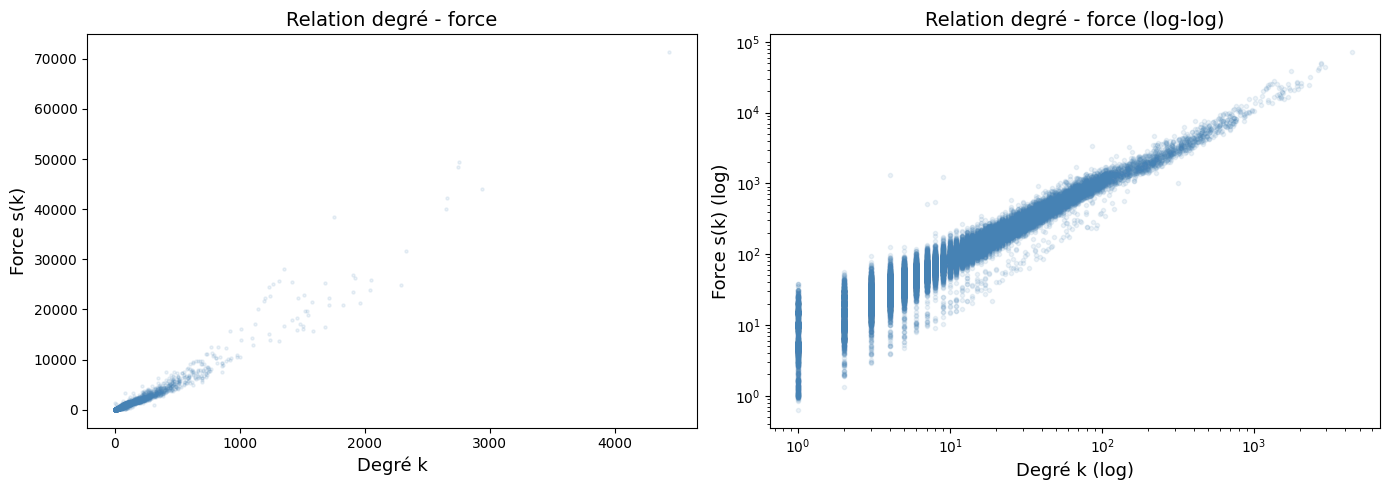

In [49]:
degree_vals = [G_weighted.degree(n) for n in G_weighted.nodes()]
strength_vals = [strength[n] for n in G_weighted.nodes()]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot degré vs force
axes[0].scatter(degree_vals, strength_vals, alpha=0.1, s=5, color='steelblue')
axes[0].set_xlabel('Degré k', size=13)
axes[0].set_ylabel('Force s(k)', size=13)
axes[0].set_title('Relation degré - force', size=14)

# En log-log
axes[1].loglog(degree_vals, strength_vals, 'o', alpha=0.1, markersize=3, color='steelblue')
axes[1].set_xlabel('Degré k (log)', size=13)
axes[1].set_ylabel('Force s(k) (log)', size=13)
axes[1].set_title('Relation degré - force (log-log)', size=14)

plt.tight_layout()
plt.show()

## Étape 5 : Analyse des flux dominants

On identifie les **corridors migratoires les plus importants** : les paires de villes avec les plus grands volumes de migration.

In [47]:
# Top 20 des flux migratoires
edges_with_weight = [
    (u, v, d['nb_migrations'])
    for u, v, d in G_weighted.edges(data=True)
]
top20_flows = sorted(edges_with_weight, key=lambda x: x[2], reverse=True)[:20]

print("Top 20 des corridors migratoires :")
print("-" * 50)
print(f"{'Rang':>4} | {'Départ':>7} → {'Arrivée':>7} | {'Migrations':>10}")
print("-" * 50)
for rank, (src, tgt, vol) in enumerate(top20_flows, 1):
    print(f"{rank:4} | {src:>7} → {tgt:>7} | {vol:>10,}")

Top 20 des corridors migratoires :
--------------------------------------------------
Rang |  Départ → Arrivée | Migrations
--------------------------------------------------
   1 | Mérignac → Bordeaux | 1,599.60122852842
   2 | Sainte-Florence → Essarts-en-Bocage | 1,318.10054285679
   3 | Villeurbanne → Lyon 3e Arrondissement | 1,237.90614432366
   4 | Saint-Herblain →  Nantes | 1,206.26761861947
   5 | Talence → Bordeaux | 1,189.51289103241
   6 |   L'Oie → Essarts-en-Bocage | 1,178.77130203621
   7 |    Rezé →  Nantes | 1,023.9466155915
   8 |  Bègles → Bordeaux | 1,002.02881162316
   9 | Schiltigheim → Strasbourg | 1,000.5300138883
  10 | Castelnau-le-Lez → Montpellier | 981.206439687231
  11 | Lyon 3e Arrondissement → Villeurbanne | 976.789016268191
  12 | Paris 20e Arrondissement → Paris 11e Arrondissement | 945.139070643315
  13 | Lyon 3e Arrondissement → Lyon 7e Arrondissement | 932.697427375749
  14 | Paris 15e Arrondissement → Paris 14e Arrondissement | 887.125282410425
  15

## Étape 6 : Distribution des volumes de migration

On analyse la distribution statistique des volumes de migration par lien.

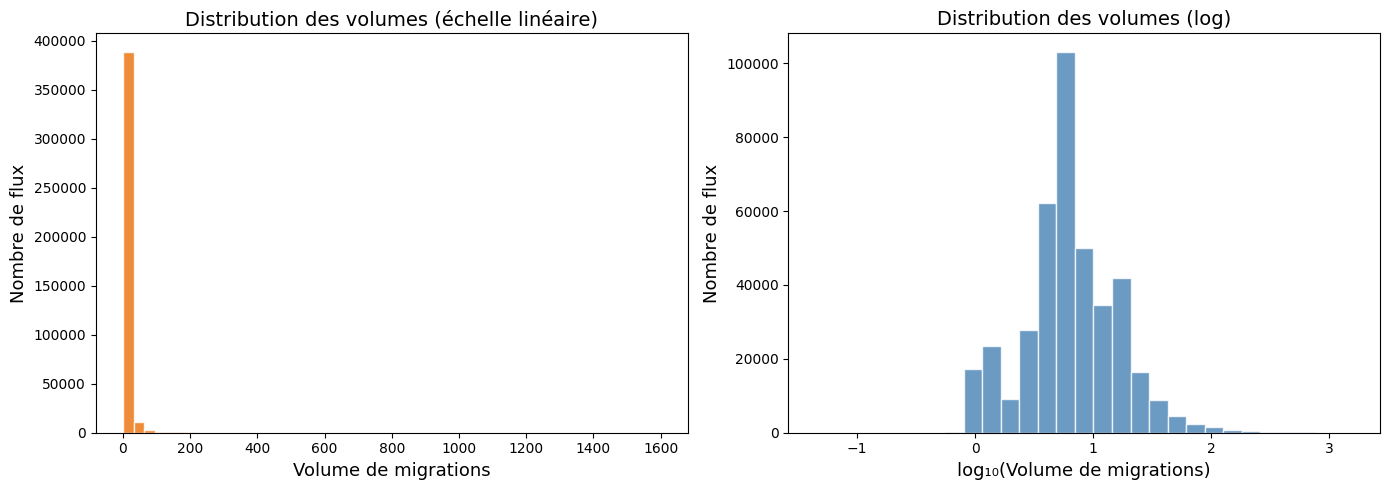

Volume moyen par flux : 11 personnes
Volume médian par flux : 5 personnes
Volume maximum : 1,599.60122852842 personnes


In [ ]:
volumes = [d['nb_migrations'] for u, v, d in G_weighted.edges(data=True)]
volumes = [v for v in volumes if v > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme linéaire
axes[0].hist(volumes, bins=50, color='#EB7009', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Volume de migrations', size=13)
axes[0].set_ylabel('Nombre de flux', size=13)
axes[0].set_title('Distribution des volumes (échelle linéaire)', size=14)

# Histogramme log-log
log_volumes = np.log10([v for v in volumes if v > 0])
bins = np.linspace(min(log_volumes), max(log_volumes), 30)
axes[1].hist(log_volumes, bins=bins, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('log₁₀(Volume de migrations)', size=13)
axes[1].set_ylabel('Nombre de flux', size=13)
axes[1].set_title('Distribution des volumes (log)', size=14)

plt.tight_layout()
plt.show()

print(f"Volume moyen par flux : {np.mean(volumes):.0f} personnes")
print(f"Volume médian par flux : {np.median(volumes):.0f} personnes")
print(f"Volume maximum : {max(volumes):,} personnes")

---

## Résumé des résultats

### Conclusions principales

1. **Réseau sans échelle** : la distribution des degrés suit une loi de puissance, caractéristique des systèmes complexes réels.

2. **Hubs migratoires** : quelques grandes métropoles (Paris, Lyon, Marseille…) concentrent l'essentiel des flux.


4. **Avec les volumes** : on peut identifier les corridors migratoires les plus importants et mesurer l'attractivité réelle des villes.

### Pistes d'analyse supplémentaires
- Détection de communautés (zones d'attraction migratoire)
- Corrélation avec des variables socio-économiques (emploi, prix immobilier)
- Simulation de l'impact de la suppression de hubs (résilience du réseau)

In [52]:
# Chargement des flux (graphe non pondéré)
df = pd.read_csv(
    "edges_mobilites.csv",
    dtype={"source": str, "target": str}
)

# Chargement des flux avec volumes (graphe pondéré)
df_weighted = pd.read_csv(
    "edges_mobilites_nb.csv",
    dtype={"source": str, "target": str, "nb_migrations": float}
)

In [53]:
# Construction des graphes
G = nx.from_pandas_edgelist(df, source="source", target="target", create_using=nx.DiGraph())

G_weighted = nx.from_pandas_edgelist(
    df_weighted,
    source='source',
    target='target',
    edge_attr='nb_migrations',
    create_using=nx.DiGraph()
)

# Graphe non orienté (nécessaire pour la détection de communautés)
G_undirected = G.to_undirected()
G_weighted_undirected = G_weighted.to_undirected(reciprocal=False)

print(f"Graphe orienté       : {G.number_of_nodes():,} nœuds, {G.number_of_edges():,} arêtes")
print(f"Graphe non orienté   : {G_undirected.number_of_nodes():,} nœuds, {G_undirected.number_of_edges():,} arêtes")
print(f"Graphe pondéré (DiG) : {G_weighted.number_of_nodes():,} nœuds, {G_weighted.number_of_edges():,} arêtes")

Graphe orienté       : 30,782 nœuds, 404,835 arêtes
Graphe non orienté   : 30,782 nœuds, 353,651 arêtes
Graphe pondéré (DiG) : 30,782 nœuds, 404,835 arêtes


---
# PARTIE 1 : Détection de communautés

Les **communautés** sont des groupes de villes plus densément connectées entre elles qu'avec le reste du réseau. Dans le contexte des migrations résidentielles, elles correspondent à des **zones d'attraction migratoire** : des bassins dans lesquels les gens migrent préférentiellement, révélant des logiques de proximité géographique, économique ou culturelle.

Deux méthodes complémentaires sont proposées :
- **Algorithme de Louvain** : rapide, basé sur l'optimisation de la modularité, recommandé pour les grands graphes
- **Girvan-Newman** : basé sur la suppression itérative des arêtes à forte centralité, plus interprétable mais plus coûteux en calcul

## 1.1 Algorithme de Louvain

L'algorithme de Louvain optimise la **modularité** $Q$ du partitionnement :

$$Q = \frac{1}{2m} \sum_{ij} \left[ A_{ij} - \frac{k_i k_j}{2m} \right] \delta(c_i, c_j)$$

où $A_{ij}$ est la matrice d'adjacence, $k_i$ le degré du nœud $i$, $m$ le nombre d'arêtes, et $\delta(c_i, c_j) = 1$ si $i$ et $j$ appartiennent à la même communauté.

Une modularité $Q > 0.3$ indique une structure de communautés significative.

In [ ]:
# Détection des communautés avec l'algorithme de Louvain
# resolution > 1 → plus de petites communautés ; < 1 → moins de grandes communautés
partition = community_louvain.best_partition(G_undirected, resolution=1.0, random_state=42)

# Calcul de la modularité
modularity = community_louvain.modularity(partition, G_undirected)

# Statistiques sur les communautés
n_communities = len(set(partition.values()))
community_sizes = pd.Series(partition.values()).value_counts().sort_values(ascending=False)

print(f"Nombre de communautés détectées : {n_communities}")
print(f"Modularité Q                    : {modularity:.4f}")
print(f"\nTop 10 des communautés par taille :")
print("-" * 35)
for comm_id, size in community_sizes.head(10).items():
    print(f"  Communauté {comm_id:3d} : {size:4d} villes")

Nombre de communautés détectées : 30
Modularité Q                    : 0.5140

Top 10 des communautés par taille :
-----------------------------------
  Communauté  21 : 5731 villes
  Communauté   8 : 3735 villes
  Communauté   2 : 3650 villes
  Communauté   5 : 3583 villes
  Communauté  20 : 3361 villes
  Communauté   3 : 3145 villes
  Communauté   4 : 2524 villes
  Communauté   9 : 2389 villes
  Communauté  12 : 1449 villes
  Communauté   6 : 1175 villes
Installez python-louvain pour exécuter cette cellule : pip install python-louvain


In [56]:
# Analyse des communautés majeures
major_communities = community_sizes[community_sizes >= community_sizes.quantile(0.75)].index.tolist()

print("Communautés majeures (>= 75e percentile de taille) :")
print("-" * 55)

for comm_id in major_communities[:10]:
    # Villes de cette communauté
    cities_in_comm = [node for node, c in partition.items() if c == comm_id]
    size = len(cities_in_comm)

    # Degré moyen des villes de la communauté
    degrees = [G_undirected.degree(c) for c in cities_in_comm]
    avg_degree = np.mean(degrees)

    # Ville centrale (hub) = ville avec le plus fort degré dans la communauté
    hub = cities_in_comm[np.argmax(degrees)]

    print(f"  Communauté {comm_id:3d} | {size:4d} villes | Degré moyen : {avg_degree:.1f} | Hub : {hub}")

Communautés majeures (>= 75e percentile de taille) :
-------------------------------------------------------
  Communauté  21 | 5731 villes | Degré moyen : 20.4 | Hub : Dijon
  Communauté   8 | 3735 villes | Degré moyen : 14.3 | Hub : Strasbourg
  Communauté   2 | 3650 villes | Degré moyen : 18.7 | Hub : Toulouse
  Communauté   5 | 3583 villes | Degré moyen : 20.4 | Hub : Bordeaux
  Communauté  20 | 3361 villes | Degré moyen : 45.0 | Hub : Reims
  Communauté   3 | 3145 villes | Degré moyen : 17.2 | Hub : Lille
  Communauté   4 | 2524 villes | Degré moyen : 31.3 | Hub : Nantes
  Communauté   9 | 2389 villes | Degré moyen : 16.1 | Hub : Rouen


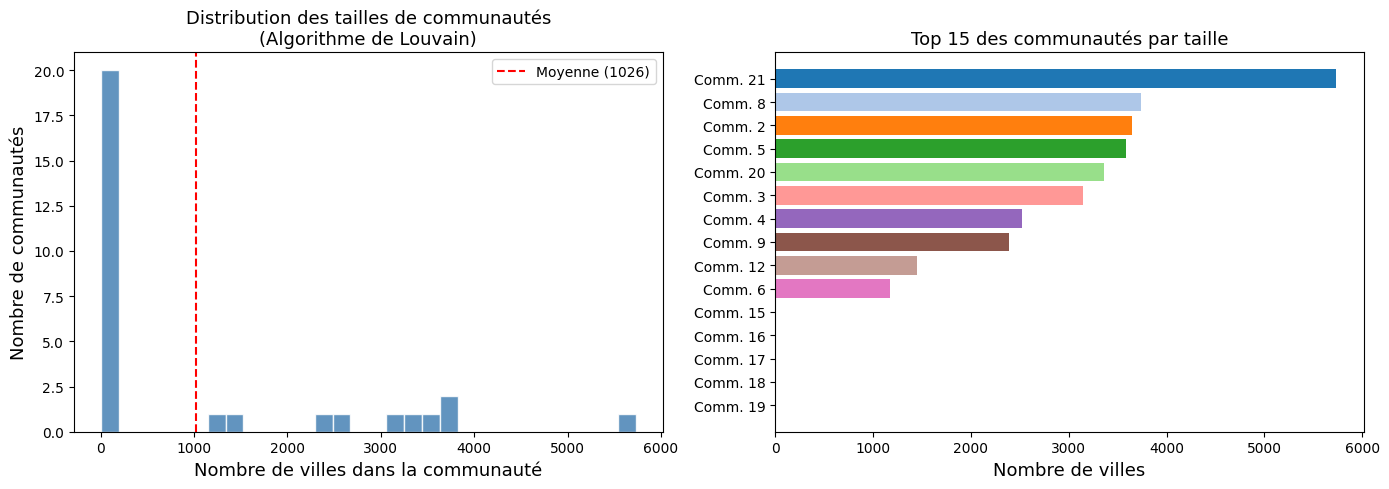


Modularité Q = 0.5140
→ Structure de communautés significative (Q > 0.3)


In [57]:
# Distribution de la taille des communautés
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme des tailles
axes[0].hist(community_sizes.values, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Nombre de villes dans la communauté', size=13)
axes[0].set_ylabel('Nombre de communautés', size=13)
axes[0].set_title('Distribution des tailles de communautés\n(Algorithme de Louvain)', size=13)
axes[0].axvline(community_sizes.mean(), color='red', linestyle='--', label=f'Moyenne ({community_sizes.mean():.0f})')
axes[0].legend()

# Top 15 des communautés
top15 = community_sizes.head(15)
colors = plt.cm.tab20(np.linspace(0, 1, len(top15)))
axes[1].barh([f"Comm. {i}" for i in top15.index], top15.values, color=colors)
axes[1].set_xlabel('Nombre de villes', size=13)
axes[1].set_title('Top 15 des communautés par taille', size=13)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print(f"\nModularité Q = {modularity:.4f}")
if modularity > 0.3:
    print("→ Structure de communautés significative (Q > 0.3)")
else:
    print("→ Structure de communautés modérée (Q ≤ 0.3)")

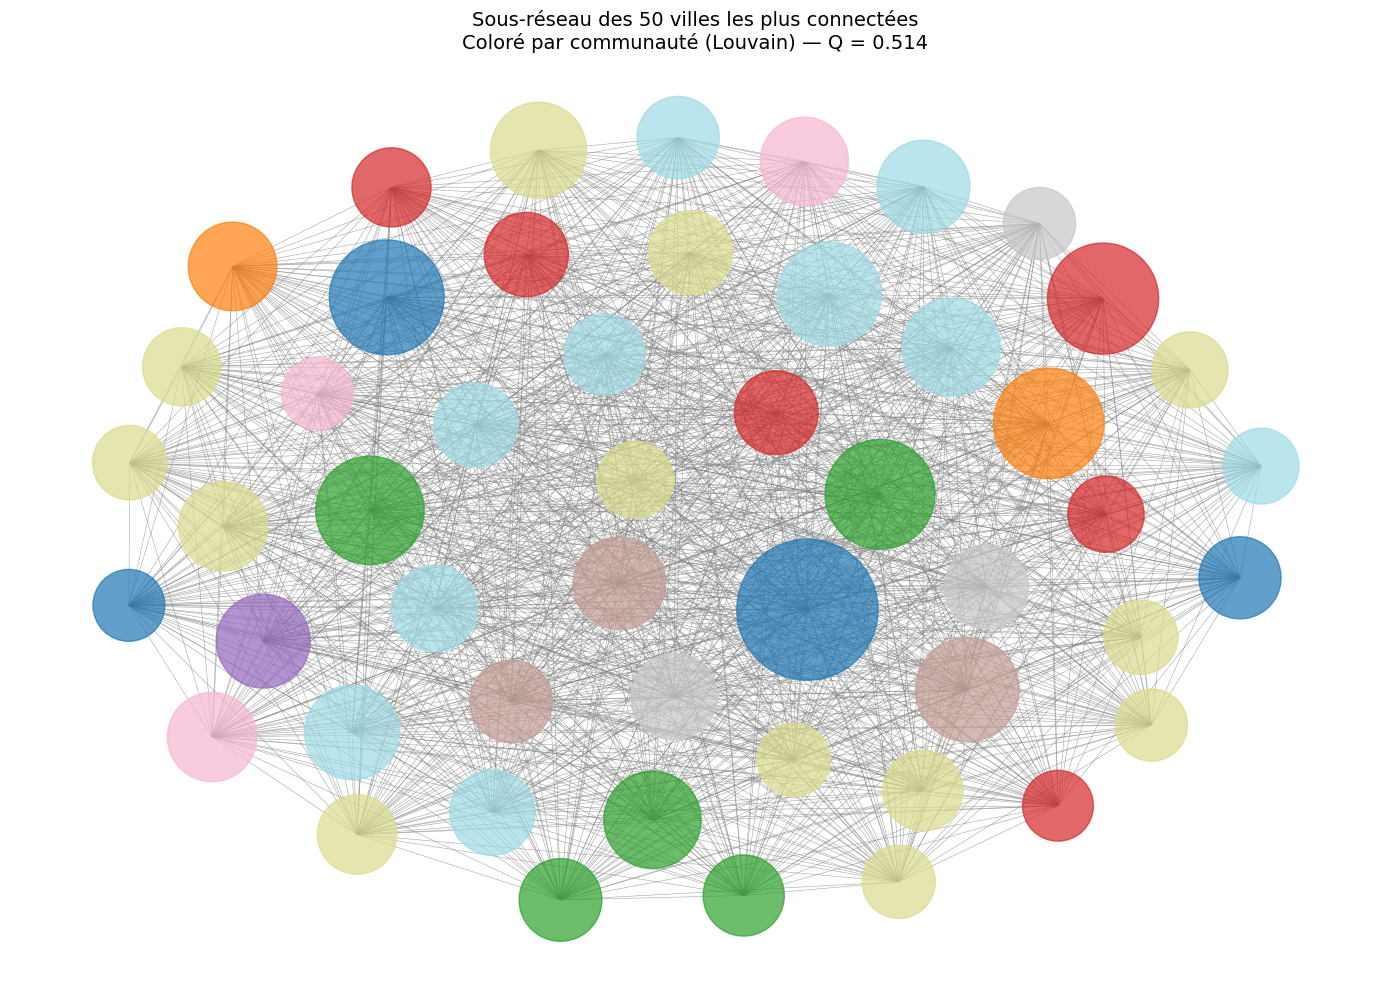

In [59]:
# Visualisation du réseau coloré par communauté (sous-graphe des nœuds les plus connectés)
# On extrait les N villes les plus connectées pour une visualisation lisible
N_TOP = 50
top_nodes = sorted(G_undirected.degree(), key=lambda x: x[1], reverse=True)[:N_TOP]
top_node_names = [n for n, d in top_nodes]

H = G_undirected.subgraph(top_node_names)

# Couleurs par communauté
unique_communities = list(set(partition[n] for n in H.nodes()))
color_map = plt.cm.tab20(np.linspace(0, 1, len(unique_communities)))
comm_to_color = {c: color_map[i] for i, c in enumerate(unique_communities)}
node_colors = [comm_to_color[partition[n]] for n in H.nodes()]

# Taille des nœuds proportionnelle au degré
node_sizes = [G_undirected.degree(n) * 3 for n in H.nodes()]

fig, ax = plt.subplots(figsize=(14, 10))
pos = nx.spring_layout(H, seed=42, k=0.8)
nx.draw_networkx(
    H, pos=pos,
    node_color=node_colors,
    node_size=node_sizes,
    with_labels=False,
    edge_color='gray',
    alpha=0.7,
    width=0.4,
    ax=ax
)
ax.set_title(
    f"Sous-réseau des {N_TOP} villes les plus connectées\nColoré par communauté (Louvain) — Q = {modularity:.3f}",
    size=14
)
ax.axis('off')
plt.tight_layout()
plt.show()

## 1.2 Louvain sur le graphe pondéré

Lorsque les volumes de migration sont disponibles, on peut utiliser les **poids des arêtes** dans la détection de communautés. Cela favorise la formation de communautés basées sur l'intensité réelle des flux plutôt que sur leur simple présence.

In [63]:
# Détection sur le graphe pondéré
partition_w = community_louvain.best_partition(
    G_weighted_undirected,
    weight='nb_migrations',
    resolution=1.0,
    random_state=42
)
modularity_w = community_louvain.modularity(partition_w, G_weighted_undirected, weight='nb_migrations')
n_communities_w = len(set(partition_w.values()))
community_sizes_w = pd.Series(partition_w.values()).value_counts().sort_values(ascending=False)

print("=== Louvain non pondéré ===")
print(f"  Communautés : {n_communities}     | Modularité Q = {modularity:.4f}")
print()
print("=== Louvain pondéré (volumes de migration) ===")
print(f"  Communautés : {n_communities_w}     | Modularité Q = {modularity_w:.4f}")
print()

# Comparaison : dans quelles communautés les villes se trouvent-elles ?
# Calcul du NMI (Normalized Mutual Information) comme mesure de similarité
from sklearn.metrics import normalized_mutual_info_score
common_nodes = list(set(partition.keys()) & set(partition_w.keys()))
labels_a = [partition[n] for n in common_nodes]
labels_b = [partition_w[n] for n in common_nodes]
nmi = normalized_mutual_info_score(labels_a, labels_b)
print(f"Similarité entre partitionnements (NMI) : {nmi:.4f}")
print("  → NMI proche de 1 = partitionnements très similaires")
print("  → NMI proche de 0 = partitionnements très différents")

=== Louvain non pondéré ===
  Communautés : 30     | Modularité Q = 0.5140

=== Louvain pondéré (volumes de migration) ===
  Communautés : 41     | Modularité Q = 0.6260

Similarité entre partitionnements (NMI) : 0.6597
  → NMI proche de 1 = partitionnements très similaires
  → NMI proche de 0 = partitionnements très différents


## 1.3 Méthode Girvan-Newman

La méthode **Girvan-Newman** détecte les communautés en retirant itérativement les arêtes ayant la plus haute **centralité d'intermédiarité** (*edge betweenness centrality*). Ces arêtes sont celles qui servent de «ponts» entre des groupes de villes.

> ⚠️ Cette méthode est coûteuse en calcul. Elle est appliquée ici sur un **sous-graphe des N villes les plus connectées** pour rester raisonnable.

In [64]:
# Sous-graphe des villes les plus connectées pour Girvan-Newman
N_GN = 100  # Ajustez selon votre puissance de calcul (50-200 recommandé)

top_nodes_gn = sorted(G_undirected.degree(), key=lambda x: x[1], reverse=True)[:N_GN]
top_node_names_gn = [n for n, d in top_nodes_gn]
H_gn = G_undirected.subgraph(top_node_names_gn).copy()

print(f"Sous-graphe Girvan-Newman : {H_gn.number_of_nodes()} nœuds, {H_gn.number_of_edges()} arêtes")

Sous-graphe Girvan-Newman : 100 nœuds, 4384 arêtes


In [65]:
from networkx.algorithms.community import girvan_newman

# Exécution de Girvan-Newman — on s'arrête à k_target communautés
k_target = 8  # Nombre de communautés souhaité

gn_generator = girvan_newman(H_gn)

# Itération jusqu'au nombre de communautés souhaité
for communities_gn in gn_generator:
    if len(communities_gn) >= k_target:
        break

# Calcul de la modularité
modularity_gn = nx.community.modularity(H_gn, communities_gn)

print(f"Nombre de communautés détectées : {len(communities_gn)}")
print(f"Modularité Q                    : {modularity_gn:.4f}")
print()
print("Taille des communautés :")
for i, comm in enumerate(sorted(communities_gn, key=len, reverse=True)):
    print(f"  Communauté {i+1} : {len(comm)} villes")

Nombre de communautés détectées : 8
Modularité Q                    : -0.0005

Taille des communautés :
  Communauté 1 : 93 villes
  Communauté 2 : 1 villes
  Communauté 3 : 1 villes
  Communauté 4 : 1 villes
  Communauté 5 : 1 villes
  Communauté 6 : 1 villes
  Communauté 7 : 1 villes
  Communauté 8 : 1 villes


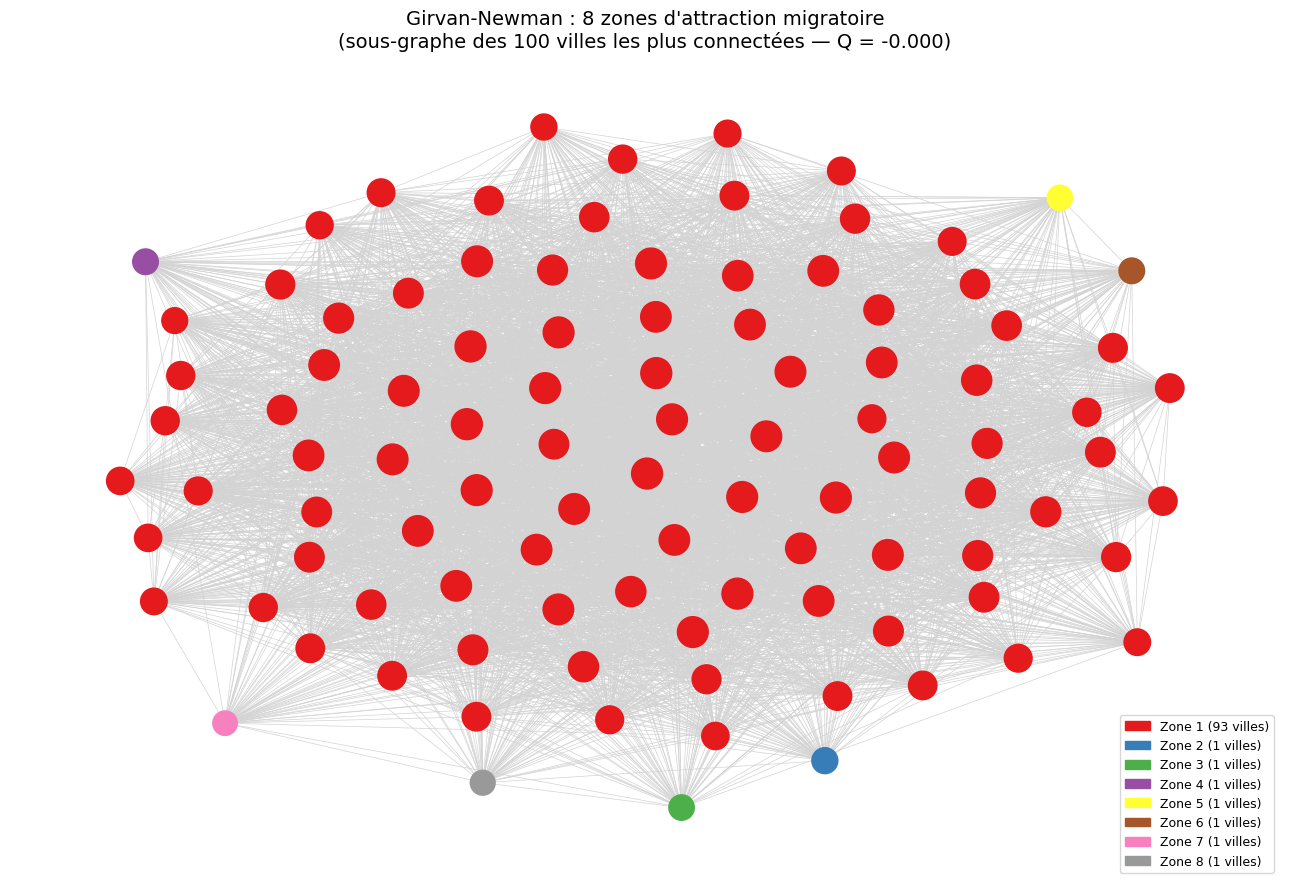

In [66]:
# Visualisation Girvan-Newman
fig, ax = plt.subplots(figsize=(13, 9))

# Attribution couleur par communauté
color_palette = plt.cm.Set1(np.linspace(0, 1, len(communities_gn)))
node_to_color_gn = {}
for i, comm in enumerate(communities_gn):
    for node in comm:
        node_to_color_gn[node] = color_palette[i]

colors_gn = [node_to_color_gn[n] for n in H_gn.nodes()]
sizes_gn = [H_gn.degree(n) * 5 for n in H_gn.nodes()]

pos_gn = nx.spring_layout(H_gn, seed=0, k=1.2)
nx.draw_networkx(
    H_gn, pos=pos_gn,
    node_color=colors_gn,
    node_size=sizes_gn,
    with_labels=False,
    edge_color='lightgray',
    width=0.5,
    ax=ax
)

# Légende
legend_patches = [
    plt.matplotlib.patches.Patch(color=color_palette[i], label=f"Zone {i+1} ({len(c)} villes)")
    for i, c in enumerate(sorted(communities_gn, key=len, reverse=True))
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)
ax.set_title(
    f"Girvan-Newman : {len(communities_gn)} zones d'attraction migratoire\n"
    f"(sous-graphe des {N_GN} villes les plus connectées — Q = {modularity_gn:.3f})",
    size=14
)
ax.axis('off')
plt.tight_layout()
plt.show()

In [67]:
# Analyse du contenu des communautés Girvan-Newman
print("Contenu des communautés Girvan-Newman (hub = ville la plus connectée) :")
print("=" * 65)

for i, comm in enumerate(sorted(communities_gn, key=len, reverse=True)):
    # Hub = nœud de plus fort degré dans la communauté
    hub_gn = max(comm, key=lambda n: G_undirected.degree(n))
    degrees_comm = [G_undirected.degree(n) for n in comm]
    subH = H_gn.subgraph(list(comm))
    internal_edges = subH.number_of_edges()
    print(f"\nZone {i+1} | {len(comm)} villes | Hub : {hub_gn} (degré global : {G_undirected.degree(hub_gn)})")
    print(f"         | Arêtes internes : {internal_edges} | Degré moyen local : {np.mean(degrees_comm):.1f}")

Contenu des communautés Girvan-Newman (hub = ville la plus connectée) :

Zone 1 | 93 villes | Hub : Toulouse (degré global : 3450)
         | Arêtes internes : 3931 | Degré moyen local : 1032.3

Zone 2 | 1 villes | Hub : La Roche-sur-Yon (degré global : 619)
         | Arêtes internes : 0 | Degré moyen local : 619.0

Zone 3 | 1 villes | Hub : Montluçon (degré global : 621)
         | Arêtes internes : 0 | Degré moyen local : 621.0

Zone 4 | 1 villes | Hub : Béziers (degré global : 614)
         | Arêtes internes : 0 | Degré moyen local : 614.0

Zone 5 | 1 villes | Hub : Saint-Martin-d'Hères (degré global : 606)
         | Arêtes internes : 0 | Degré moyen local : 606.0

Zone 6 | 1 villes | Hub : Colmar (degré global : 585)
         | Arêtes internes : 0 | Degré moyen local : 585.0

Zone 7 | 1 villes | Hub : Narbonne (degré global : 581)
         | Arêtes internes : 0 | Degré moyen local : 581.0

Zone 8 | 1 villes | Hub : Tarbes (degré global : 616)
         | Arêtes internes : 0 | Degr

## 1.4 Comparaison Louvain vs Girvan-Newman

| Critère | Louvain | Girvan-Newman |
|---|---|---|
| **Complexité** | O(n log n) — très rapide | O(m² n) — lent sur grands graphes |
| **Résolution** | Paramétrable (`resolution`) | Contrôle du nombre de coupes |
| **Pondération** | Supporte les poids | Supporte les poids (betweenness pondérée) |
| **Déterminisme** | Stochastique (seed fixable) | Déterministe |
| **Usage recommandé** | Grands réseaux (>1000 nœuds) | Analyse fine de sous-réseaux |

---
# PARTIE 2 : Modèle Gravitaire

Le **modèle gravitaire** est l'un des modèles les plus robustes pour expliquer et prédire les flux migratoires. Inspiré de la loi de gravitation universelle, il postule que les migrations entre deux villes sont :
- **proportionnelles** à leur population (masse)
- **inversement proportionnelles** à la distance qui les sépare

$$F_{ij} = G \cdot \frac{P_i^{\alpha} \cdot P_j^{\beta}}{d_{ij}^{\gamma}}$$

où $F_{ij}$ est le flux migratoire, $P_i$ et $P_j$ les populations, $d_{ij}$ la distance, et $G$, $\alpha$, $\beta$, $\gamma$ des paramètres à estimer.

> **Note** : Ce notebook suppose que vous disposez de données de population et de distance entre villes. Des exemples de chargement sont fournis ci-dessous.

## 2.1 Chargement des données de population et distances

Deux options selon vos données disponibles :
- **Option A** : vous avez un fichier `communes.csv` avec les colonnes `code_insee`, `population`, `latitude`, `longitude`
- **Option B** : vous avez un fichier `distances.csv` avec les colonnes `source`, `target`, `distance_km`

In [ ]:
# ============================================================
# OPTION A : Chargement d'un fichier communes avec coordonnées
# Décommentez et adaptez si vous avez ce type de fichier
# ============================================================

df_communes = pd.read_csv(
    "communes.csv",
    dtype={"code_insee": str},
    usecols=["code_insee", "population", "latitude", "longitude"]
)
df_communes = df_communes.set_index("code_insee")
print(df_communes.head())

df_weighted = pd.read_csv(
    "edges_mobilites_nb_code_insee.csv",
    dtype={"source": str, "target": str, "nb_migrations": float}
)
print(df_weighted.head())

            longitude  latitude  population
code_insee                                 
69381           4.827    45.770       29573
69382           4.823    45.746       30325
69383           4.876    45.751      101496
69384           4.826    45.780       35263
69385           4.804    45.756       48665
  source target  nb_migrations
0  01001  01093       9.817143
1  01001  01389       4.908571
2  01001  01412      19.634286
3  01001  13117      19.634286
4  01001  30046       4.908571


## 2.2 Calcul des distances géographiques

On utilise la **formule de Haversine** pour calculer la distance à vol d'oiseau entre deux points géographiques.

In [76]:
def haversine_km(lat1, lon1, lat2, lon2):
    """Distance en km entre deux points (lat/lon en degrés) — formule de Haversine."""
    R = 6371.0  # Rayon terrestre en km
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2)**2
    return 2 * R * np.arcsin(np.sqrt(a))


# Construction du DataFrame des paires (source, target) avec volumes
# On ne garde que les paires pour lesquelles on a des données dans les deux fichiers
df_gravity = df_weighted.copy()

# Filtre : source et target présents dans df_communes
known_cities = set(df_communes.index)
df_gravity = df_gravity[
    df_gravity['source'].isin(known_cities) &
    df_gravity['target'].isin(known_cities)
].copy()

# Suppression des flux nuls
df_gravity = df_gravity[df_gravity['nb_migrations'] > 0].copy()

# Ajout des données de population
df_gravity['pop_source'] = df_gravity['source'].map(df_communes['population'])
df_gravity['pop_target'] = df_gravity['target'].map(df_communes['population'])

# Calcul de la distance
df_gravity['distance_km'] = haversine_km(
    df_gravity['source'].map(df_communes['latitude']).values,
    df_gravity['source'].map(df_communes['longitude']).values,
    df_gravity['target'].map(df_communes['latitude']).values,
    df_gravity['target'].map(df_communes['longitude']).values
)

# Suppression des auto-boucles (distance = 0)
df_gravity = df_gravity[df_gravity['distance_km'] > 0].copy()

print(f"Paires disponibles pour le modèle : {len(df_gravity):,}")
print(f"Volume total couvert              : {df_gravity['nb_migrations'].sum():,.0f} migrations")
df_gravity[['source', 'target', 'nb_migrations', 'pop_source', 'pop_target', 'distance_km']].head()

Paires disponibles pour le modèle : 403,634
Volume total couvert              : 4,244,888 migrations


,source,target,nb_migrations,pop_source,pop_target,distance_km
0,01001,01093,9.817143,876,5462,4.148132
1,01001,01389,4.908571,876,1999,10.286504
2,01001,01412,19.634286,876,615,3.395019
3,01001,13117,19.634286,876,37134,301.739772
4,01001,30046,4.908571,876,1001,247.128954


## 2.3 Analyse exploratoire : flux vs distance et population

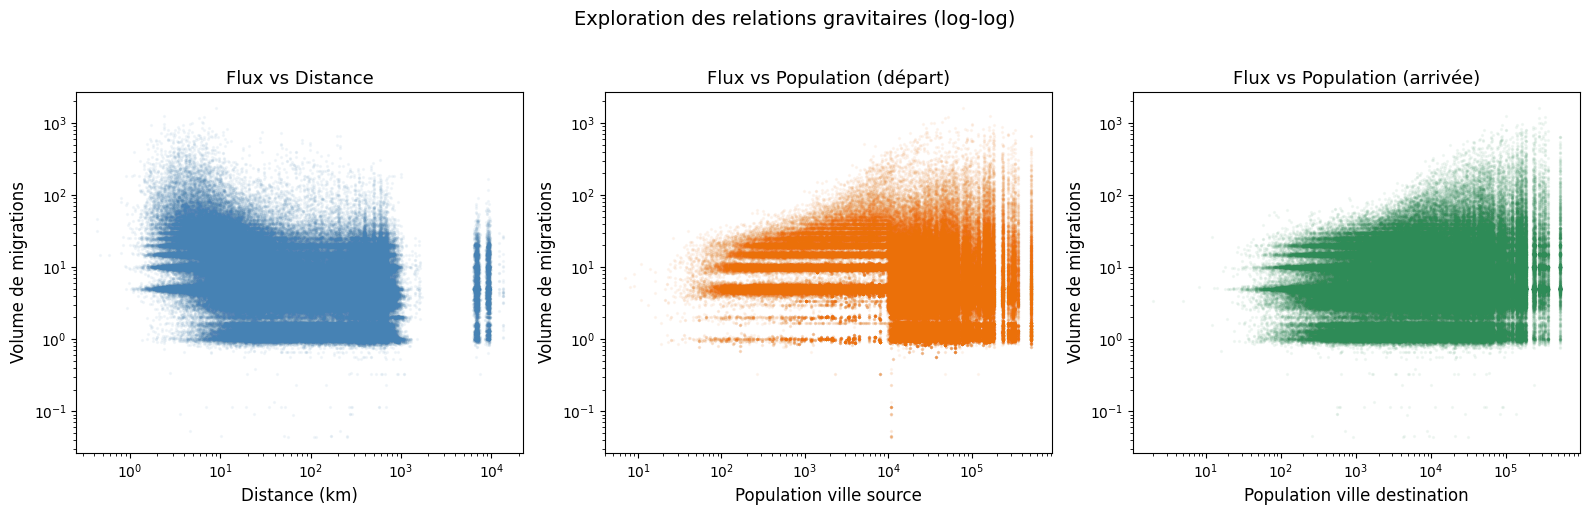

In [77]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

alpha = 0.05
s = 2

# Flux vs Distance
axes[0].scatter(df_gravity['distance_km'], df_gravity['nb_migrations'],
                alpha=alpha, s=s, color='steelblue')
axes[0].set_xlabel('Distance (km)', size=12)
axes[0].set_ylabel('Volume de migrations', size=12)
axes[0].set_title('Flux vs Distance', size=13)
axes[0].set_xscale('log')
axes[0].set_yscale('log')

# Flux vs Population source
axes[1].scatter(df_gravity['pop_source'], df_gravity['nb_migrations'],
                alpha=alpha, s=s, color='#EB7009')
axes[1].set_xlabel('Population ville source', size=12)
axes[1].set_ylabel('Volume de migrations', size=12)
axes[1].set_title('Flux vs Population (départ)', size=13)
axes[1].set_xscale('log')
axes[1].set_yscale('log')

# Flux vs Population destination
axes[2].scatter(df_gravity['pop_target'], df_gravity['nb_migrations'],
                alpha=alpha, s=s, color='seagreen')
axes[2].set_xlabel('Population ville destination', size=12)
axes[2].set_ylabel('Volume de migrations', size=12)
axes[2].set_title('Flux vs Population (arrivée)', size=13)
axes[2].set_xscale('log')
axes[2].set_yscale('log')

plt.suptitle('Exploration des relations gravitaires (log-log)', size=14, y=1.02)
plt.tight_layout()
plt.show()

## 2.4 Estimation du modèle gravitaire par régression log-linéaire

On transforme le modèle multiplicatif en modèle additif en log :

$$\ln(F_{ij}) = \ln(G) + \alpha \ln(P_i) + \beta \ln(P_j) - \gamma \ln(d_{ij}) + \varepsilon$$

Les paramètres $\alpha$, $\beta$, $\gamma$ et la constante $\ln(G)$ sont estimés par OLS.

In [78]:
from scipy.stats import pearsonr

# Variables en log
log_flow     = np.log(df_gravity['nb_migrations'].values)
log_pop_src  = np.log(df_gravity['pop_source'].values)
log_pop_tgt  = np.log(df_gravity['pop_target'].values)
log_dist     = np.log(df_gravity['distance_km'].values)

# Matrice de design : [intercept, ln(P_i), ln(P_j), ln(d_ij)]
X = np.column_stack([
    np.ones(len(log_flow)),
    log_pop_src,
    log_pop_tgt,
    log_dist
])

# Régression OLS via pseudo-inverse
coeffs, residuals, rank, sv = np.linalg.lstsq(X, log_flow, rcond=None)
ln_G, alpha_est, beta_est, gamma_est = coeffs

# Prédictions et R²
log_flow_pred = X @ coeffs
ss_res = np.sum((log_flow - log_flow_pred) ** 2)
ss_tot = np.sum((log_flow - log_flow.mean()) ** 2)
r_squared = 1 - ss_res / ss_tot

# Corrélations de Pearson
r_dist, _  = pearsonr(log_dist, log_flow)
r_src, _   = pearsonr(log_pop_src, log_flow)
r_tgt, _   = pearsonr(log_pop_tgt, log_flow)

print("=" * 55)
print("    RÉSULTATS DU MODÈLE GRAVITAIRE")
print("=" * 55)
print(f"  ln(G)  (constante)      : {ln_G:+.4f}  [G = {np.exp(ln_G):.4e}]")
print(f"  α      (pop. départ)    : {alpha_est:+.4f}")
print(f"  β      (pop. arrivée)   : {beta_est:+.4f}")
print(f"  γ      (distance)       : {gamma_est:+.4f}")
print("-" * 55)
print(f"  R²                      : {r_squared:.4f}")
print("=" * 55)
print()
print("Corrélations de Pearson (log-log) :")
print(f"  ln(flux) ~ ln(distance)      : r = {r_dist:+.4f}")
print(f"  ln(flux) ~ ln(pop. départ)   : r = {r_src:+.4f}")
print(f"  ln(flux) ~ ln(pop. arrivée)  : r = {r_tgt:+.4f}")

    RÉSULTATS DU MODÈLE GRAVITAIRE
  ln(G)  (constante)      : +2.2365  [G = 9.3609e+00]
  α      (pop. départ)    : -0.0664
  β      (pop. arrivée)   : +0.1079
  γ      (distance)       : -0.1862
-------------------------------------------------------
  R²                      : 0.1650

Corrélations de Pearson (log-log) :
  ln(flux) ~ ln(distance)      : r = -0.3267
  ln(flux) ~ ln(pop. départ)   : r = -0.2188
  ln(flux) ~ ln(pop. arrivée)  : r = +0.0943


In [79]:
# Interprétation des résultats
print("INTERPRÉTATION DES PARAMÈTRES")
print("=" * 55)

if alpha_est > 0:
    print(f"  α = {alpha_est:.3f} > 0 : les grandes villes de départ génèrent")
    print(f"  davantage de migrants (effet de taille)")
else:
    print(f"  α = {alpha_est:.3f} < 0 : les petites villes de départ sont")
    print(f"  proportionnellement plus mobiles")

print()

if beta_est > 0:
    print(f"  β = {beta_est:.3f} > 0 : les grandes villes attirent plus de migrants")
    print(f"  (attractivité proportionnelle à la masse)")
else:
    print(f"  β = {beta_est:.3f} < 0 : résultat atypique — à investiguer")

print()

if gamma_est < 0:
    print(f"  γ = {gamma_est:.3f} < 0 : effet de friction classique — la distance")
    print(f"  décourage les migrations (plus c'est loin, moins on migre)")
    print(f"  Un doublement de la distance réduit les flux d'un facteur 2^|γ| ≈ {2**abs(gamma_est):.2f}")
else:
    print(f"  γ = {gamma_est:.3f} > 0 : les flux augmentent avec la distance")
    print(f"  (migrations longue-distance dominantes dans le réseau)")

print()
print(f"  R² = {r_squared:.4f} : le modèle explique {r_squared*100:.1f}% de la variance")
print(f"  des flux (en log), {'bonne' if r_squared > 0.5 else 'modérée'} qualité d'ajustement.")

INTERPRÉTATION DES PARAMÈTRES
  α = -0.066 < 0 : les petites villes de départ sont
  proportionnellement plus mobiles

  β = 0.108 > 0 : les grandes villes attirent plus de migrants
  (attractivité proportionnelle à la masse)

  γ = -0.186 < 0 : effet de friction classique — la distance
  décourage les migrations (plus c'est loin, moins on migre)
  Un doublement de la distance réduit les flux d'un facteur 2^|γ| ≈ 1.14

  R² = 0.1650 : le modèle explique 16.5% de la variance
  des flux (en log), modérée qualité d'ajustement.


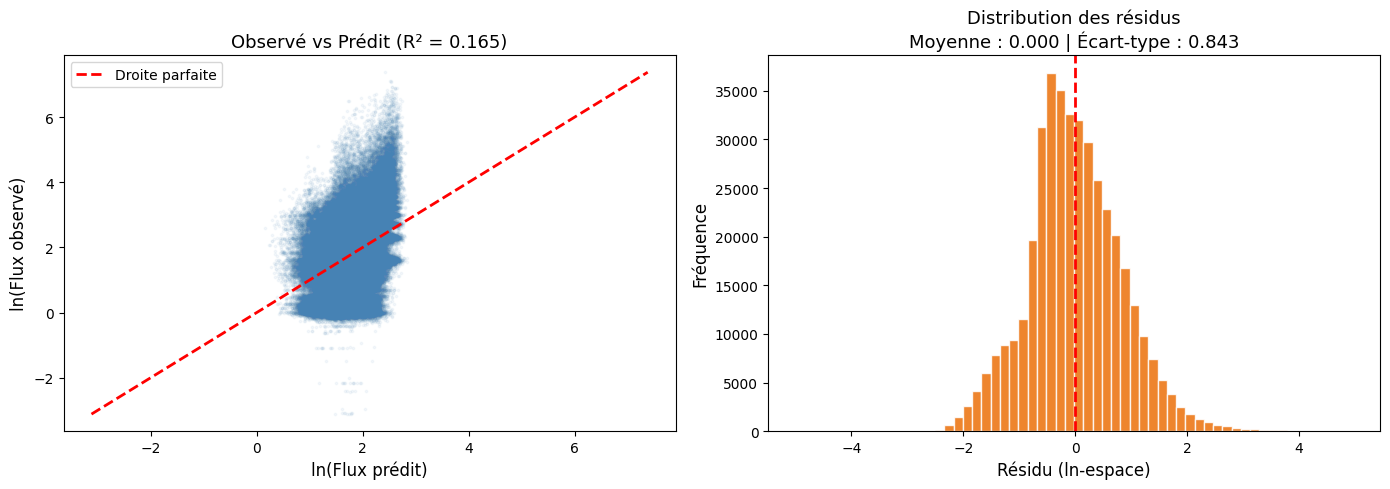

In [80]:
# Visualisation : valeurs observées vs prédites
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter log(observé) vs log(prédit)
axes[0].scatter(log_flow_pred, log_flow, alpha=0.05, s=3, color='steelblue')
axes[0].plot(
    [log_flow.min(), log_flow.max()],
    [log_flow.min(), log_flow.max()],
    'r--', linewidth=2, label='Droite parfaite'
)
axes[0].set_xlabel('ln(Flux prédit)', size=12)
axes[0].set_ylabel('ln(Flux observé)', size=12)
axes[0].set_title(f'Observé vs Prédit (R² = {r_squared:.3f})', size=13)
axes[0].legend()

# Distribution des résidus
residuals_log = log_flow - log_flow_pred
axes[1].hist(residuals_log, bins=60, color='#EB7009', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Résidu (ln-espace)', size=12)
axes[1].set_ylabel('Fréquence', size=12)
axes[1].set_title(
    f'Distribution des résidus\nMoyenne : {residuals_log.mean():.3f} | Écart-type : {residuals_log.std():.3f}',
    size=13
)

plt.tight_layout()
plt.show()

## 2.5 Analyse des résidus — identifier les flux atypiques

Les **résidus positifs** correspondent à des flux plus importants que prédit par le modèle gravitaire → attractivité spécifique non capturée par la taille et la distance.

Les **résidus négatifs** correspondent à des flux moins importants que prédit → barrières invisibles (frontières administratives, différences culturelles...).

In [81]:
# Ajout des résidus au DataFrame
df_gravity['log_flow_pred'] = log_flow_pred
df_gravity['residual']      = residuals_log
df_gravity['flux_observe']  = df_gravity['nb_migrations']
df_gravity['flux_predit']   = np.exp(log_flow_pred)
df_gravity['ratio_obs_pred'] = df_gravity['flux_observe'] / df_gravity['flux_predit']

# Flux sous-estimés (observé >> prédit) — attractivité spécifique
print("TOP 15 FLUX SOUS-ESTIMÉS PAR LE MODÈLE (attractivité non capturée) :")
print("(Ratio observé/prédit le plus élevé)")
print("-" * 70)
top_positive = df_gravity.nlargest(15, 'residual')[[
    'source', 'target', 'flux_observe', 'flux_predit', 'ratio_obs_pred', 'distance_km'
]]
print(top_positive.to_string(index=False, float_format=lambda x: f"{x:.1f}"))

print()
print("TOP 15 FLUX SURESTIMÉS PAR LE MODÈLE (barrières non capturées) :")
print("(Ratio observé/prédit le plus faible)")
print("-" * 70)
top_negative = df_gravity.nsmallest(15, 'residual')[[
    'source', 'target', 'flux_observe', 'flux_predit', 'ratio_obs_pred', 'distance_km'
]]
print(top_negative.to_string(index=False, float_format=lambda x: f"{x:.1f}"))

TOP 15 FLUX SOUS-ESTIMÉS PAR LE MODÈLE (attractivité non capturée) :
(Ratio observé/prédit le plus élevé)
----------------------------------------------------------------------
source target  flux_observe  flux_predit  ratio_obs_pred  distance_km
 33281  33063        1599.6         11.4           140.9          9.0
 31555  33063         667.3          5.6           120.2        212.6
 31555  34172         659.3          5.7           115.2        196.1
 34172  30189         721.6          7.2           100.6         46.4
 69266  69383        1237.9         12.4            99.7          2.4
 44162  44109        1206.3         12.6            95.4          6.6
 33522  33063        1189.5         12.7            93.5          5.8
 97309  97302         747.8          8.3            89.6         29.0
 35238  29019         482.8          5.5            88.2        211.3
 97422  97416         825.5          9.5            87.2         11.9
 44109  44162         793.0          9.1            8

## 2.6 Effet de la distance seul (friction distance)

On isole l'effet de la distance en regroupant les flux par intervalle de distance.

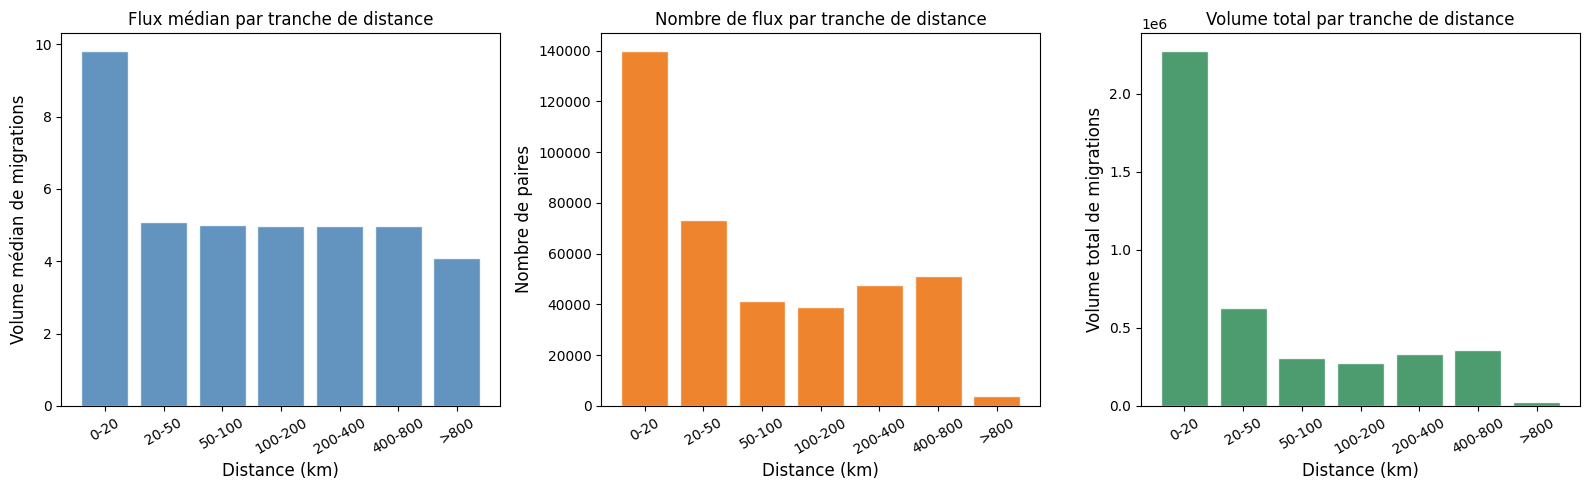

dist_bin  n_flux  flux_median  flux_mean   flux_total  dist_mean
    0-20  139984     9.822967  16.267976 2.277256e+06  10.059463
   20-50   73362     5.095659   8.523940 6.253333e+05  31.727087
  50-100   41181     4.999990   7.380203 3.039241e+05  71.484162
 100-200   38980     4.978722   6.981420 2.721358e+05 143.921156
 200-400   47497     4.966038   6.996840 3.323289e+05 298.965966
 400-800   51300     4.959654   6.961047 3.571017e+05 557.859822
    >800    3878     4.077410   5.726185 2.220615e+04 901.583668


In [82]:
# Groupement par intervalles de distance
bins_dist = [0, 20, 50, 100, 200, 400, 800, 2000]
labels_dist = ['0-20', '20-50', '50-100', '100-200', '200-400', '400-800', '>800']

df_gravity['dist_bin'] = pd.cut(
    df_gravity['distance_km'],
    bins=bins_dist,
    labels=labels_dist
)

distance_analysis = df_gravity.groupby('dist_bin', observed=True).agg(
    n_flux=('nb_migrations', 'count'),
    flux_median=('nb_migrations', 'median'),
    flux_mean=('nb_migrations', 'mean'),
    flux_total=('nb_migrations', 'sum'),
    dist_mean=('distance_km', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Volume médian par tranche de distance
axes[0].bar(distance_analysis['dist_bin'].astype(str), distance_analysis['flux_median'],
            color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Distance (km)', size=12)
axes[0].set_ylabel('Volume médian de migrations', size=12)
axes[0].set_title('Flux médian par tranche de distance', size=12)
axes[0].tick_params(axis='x', rotation=30)

# Nombre de flux par tranche
axes[1].bar(distance_analysis['dist_bin'].astype(str), distance_analysis['n_flux'],
            color='#EB7009', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Distance (km)', size=12)
axes[1].set_ylabel('Nombre de paires', size=12)
axes[1].set_title('Nombre de flux par tranche de distance', size=12)
axes[1].tick_params(axis='x', rotation=30)

# Volume total par tranche
axes[2].bar(distance_analysis['dist_bin'].astype(str), distance_analysis['flux_total'],
            color='seagreen', edgecolor='white', alpha=0.85)
axes[2].set_xlabel('Distance (km)', size=12)
axes[2].set_ylabel('Volume total de migrations', size=12)
axes[2].set_title('Volume total par tranche de distance', size=12)
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print(distance_analysis.to_string(index=False))

---
## Résumé des nouvelles analyses

### Détection de communautés

| Méthode | Usage | Points forts |
|---|---|---|
| **Louvain** | Grands réseaux | Rapide, paramétrable, supporte les poids |
| **Louvain pondéré** | Avec volumes de migration | Intègre l'intensité des flux |
| **Girvan-Newman** | Sous-réseaux, analyse fine | Interprétable, déterministe |

Les **communautés** révèlent des **bassins migratoires** : des ensembles de villes entre lesquelles les migrations sont plus fréquentes. Ces zones peuvent refléter des logiques de proximité géographique, de marché de l'emploi, ou d'appartenance régionale.

### Modèle gravitaire

Le modèle $F_{ij} = G \cdot P_i^\alpha \cdot P_j^\beta \cdot d_{ij}^\gamma$ permet de :
- **Expliquer** quelle part de la variance des flux est due à la taille et à la distance
- **Identifier** les flux atypiques (résidus élevés = attractivité ou répulsion spécifique)
- **Prédire** des flux pour des paires non observées
- **Comparer** l'effet relatif de la population d'origine (α), d'attraction (β) et de la friction distance (γ)